#**Mounting Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#**Importing Libraries**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score
)

#**Loading Dataset**


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

datax = "/content/drive/MyDrive/Archive"

train_data = os.path.join(datax, "train")
val_data = os.path.join(datax, "val")
test_data = os.path.join(datax, "test")

image_size = (224, 224)
batch_size = 32
epochs = 20

for path in [train_data, val_data, test_data]:
    print(path, "->", os.path.exists(path))

/content/drive/MyDrive/Archive/train -> True
/content/drive/MyDrive/Archive/val -> True
/content/drive/MyDrive/Archive/test -> True


#**Counting Images Per Set**

In [ ]:
def image_count(directory):
    counts = {}
    valid_extensions = (".jpg", ".jpeg", ".png")

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = os.path.join(directory, class_name)

        if not os.path.exists(class_dir):
            counts[class_name] = 0
            continue

        counts[class_name] = sum(
            file.lower().endswith(valid_extensions)
            for file in os.listdir(class_dir)
        )

    return counts

train_counts = image_count(train_data)
val_counts = image_count(val_data)
test_counts = image_count(test_data)

distribution = pd.DataFrame(
    [train_counts, val_counts, test_counts],
    index=["Train", "Validation", "Test"]
)

print("Image counts:")
display(distribution)

print("\nTotal images:", distribution.values.sum())

Image counts:


,NORMAL,PNEUMONIA
Train,1341,3875
Validation,8,8
Test,234,390



Total images: 5856


#**Distribution Plot of Classes**

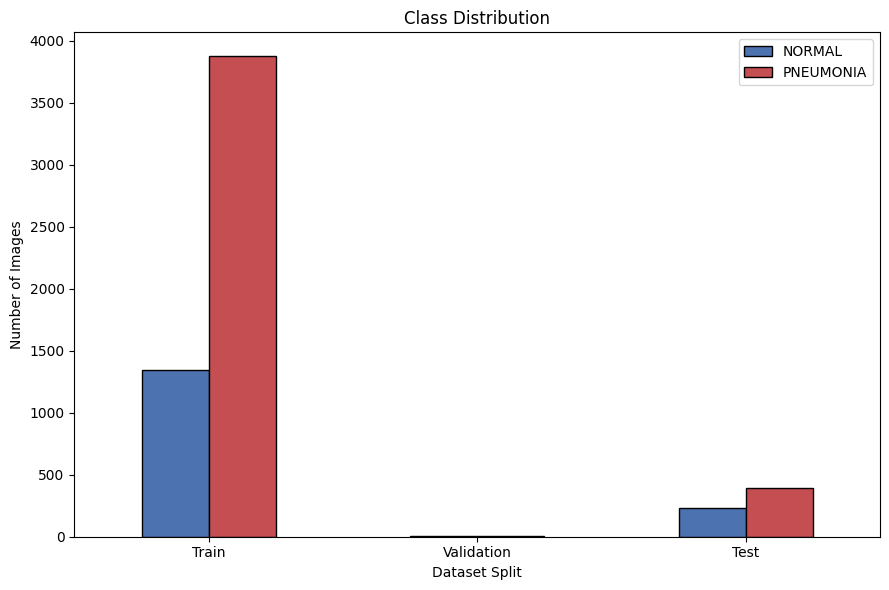

In [ ]:
plot_axis = distribution.plot(
    kind="bar", figsize=(9, 6), color=["#4C72B0", "#C44E52"], edgecolor='black'
)

plot_axis.set_title("Class Distribution")
plot_axis.set_xlabel("Dataset Split")
plot_axis.set_ylabel("Number of Images")
plot_axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

#**Chest X-Ray Image Samples**

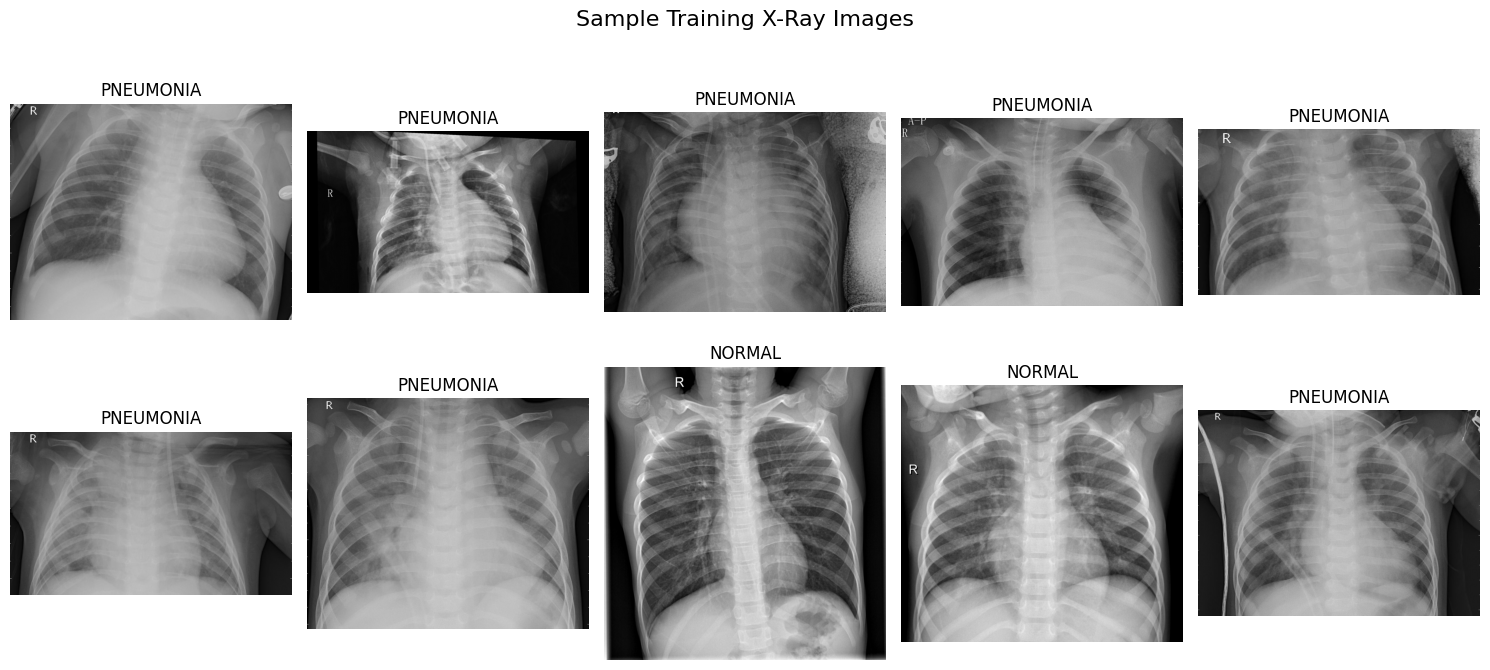

In [ ]:
def image_path(directory):
    paths = []

    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_dir = os.path.join(directory, class_name)

        for filename in os.listdir(class_dir):
            if filename.lower().endswith((".jpg", ".jpeg", ".png")): paths.append((os.path.join(class_dir, filename), class_name))

    return paths

train_path = image_path(train_data)

sample_items = random.sample(
    train_path,
    min(10, len(train_path))
)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.ravel()

for axis, (path, label) in zip(axes, sample_items):
    img = Image.open(path)

    axis.imshow(img, cmap="gray")
    axis.set_title(label)
    axis.axis("off")

for axis in axes[len(sample_items):]:
    axis.axis("off")

plt.suptitle("Sample Training X-Ray Images", fontsize=16)
plt.tight_layout()
plt.show()


# **Image Processing**

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, rotation_range=10, width_shift_range=0.10, height_shift_range=0.10, zoom_range=0.10, horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_data, target_size=image_size, batch_size=batch_size, class_mode="binary", classes=["NORMAL", "PNEUMONIA"], shuffle=True, seed=seed
)

val_gen = val_datagen.flow_from_directory(
    val_data, target_size=image_size, batch_size=batch_size, class_mode="binary", classes=["NORMAL", "PNEUMONIA"], shuffle=False
)

test_gen = val_datagen.flow_from_directory(
    test_data, target_size=image_size, batch_size=batch_size, class_mode="binary", classes=["NORMAL", "PNEUMONIA"], shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Training samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)
print("Test samples:", test_gen.samples)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Training samples: 5216
Validation samples: 16
Test samples: 624


#**Handling Class Imbalance**

In [ ]:
classes = np.unique(train_gen.classes)

weights = compute_class_weight(
    class_weight="balanced", classes=classes, y=train_gen.classes
)

class_weights = {
    int(c): float(w)
    for c, w in zip(classes, weights)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 1.9448173005219984, 1: 0.6730322580645162}


#**CNN Model Building**

In [ ]:
base_model = VGG16(
    weights="imagenet", include_top=False, input_shape=(image_size[0], image_size[1], 3)
)

base_model.trainable = False

model = Sequential([
    Input(shape=(image_size[0], image_size[1], 3)), base_model, GlobalAveragePooling2D(), Dropout(0.50), Dense(128, activation="relu"), Dropout(0.30), Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#**Model Training**

In [ ]:
model_dir = "/content/drive/MyDrive/Pneumonia_CNN_Results"
os.makedirs(model_dir, exist_ok=True)

checkpoint_path = os.path.join(
    model_dir, "best_vgg16_pneumonia.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True, verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=2, min_lr=1e-7, verbose=1
    ),

    ModelCheckpoint(
        checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1
    )
]

history = model.fit(
    train_gen, validation_data=val_gen, epochs=epochs, class_weight=class_weights, callbacks=callbacks
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5522 - loss: 2.0279 - precision: 0.7876 - recall: 0.5366
Epoch 1: val_loss improved from None to 0.67212, saving model to /content/drive/MyDrive/Pneumonia_CNN_Results/best_vgg16_pneumonia.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Pneumonia_CNN_Results/best_vgg16_pneumonia.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1430s 9s/step - accuracy: 0.6250 - loss: 1.5649 - precision: 0.8382 - recall: 0.6137 - val_accuracy: 0.7500 - val_loss: 0.6721 - val_precision: 0.8333 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.7624 - loss: 0.8630 - precision: 0.9113 - recall: 0.7521
Epoch 2: val_loss improved from 0.67212 to 0.51880, saving model to /content/drive/MyDrive/Pneumonia_CNN_Results/best_vgg16_pneumonia.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Pneumonia_CNN_Results/best_vgg16_pneumonia.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s

#**Training Vs Validation Performance**

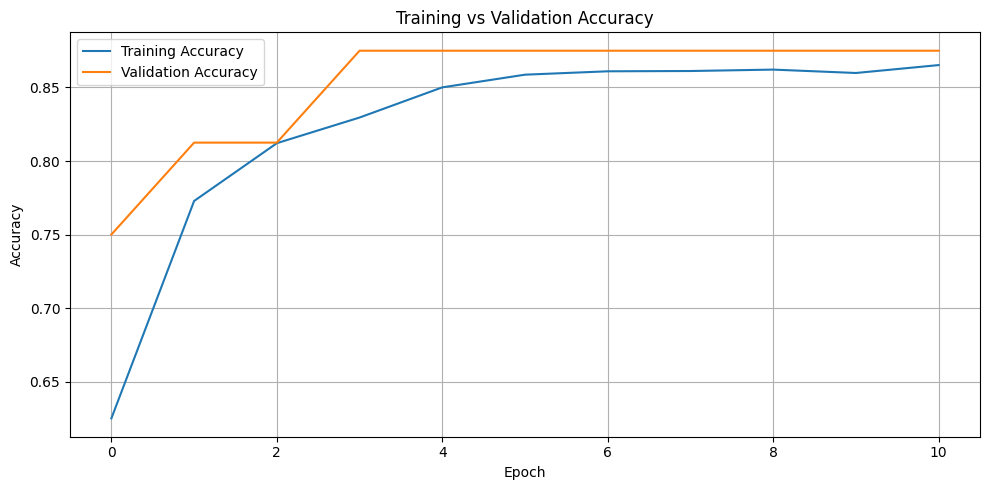

In [25]:
training_history = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(training_history["accuracy"], label="Training Accuracy")
plt.plot(training_history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

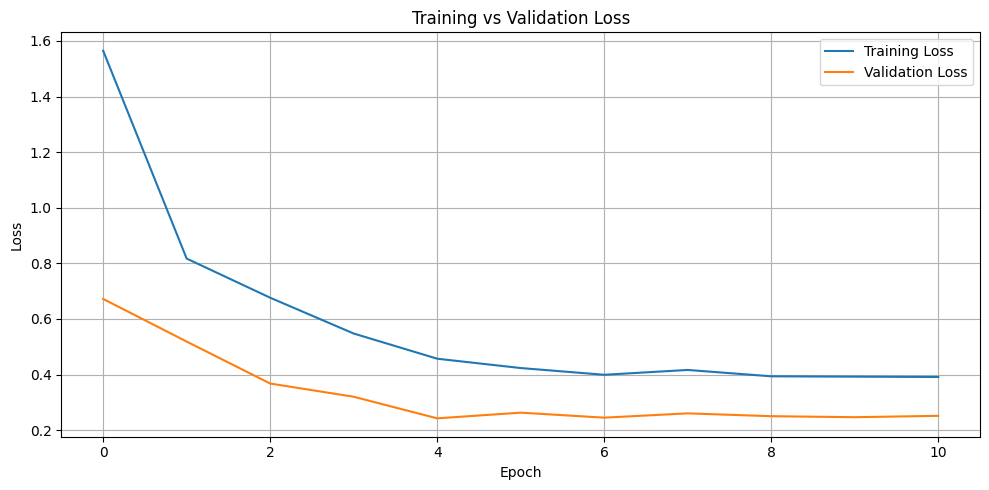

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(training_history["loss"], label="Training Loss")
plt.plot(training_history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#**Test Set Evaluation**

In [19]:
best_model = tf.keras.models.load_model(checkpoint_path)
test_gen.reset()

test_results = best_model.evaluate(
    test_gen, verbose=0
)

loss = test_results[0]
accuracy = test_results[1]
precision = test_results[2]
recall = test_results[3]

print("Test Set Results:")
print("-" * 35)
print(f"Loss        : {loss:.4f}")
print(f"Accuracy    : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision   : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall      : {recall:.4f} ({recall * 100:.2f}%)")

Test Set Results:
-----------------------------------
Loss        : 0.2983
Accuracy    : 0.8798 (87.98%)
Precision   : 0.8870 (88.70%)
Recall      : 0.9256 (92.56%)


#**Classification Report**

In [18]:
test_gen.reset()

probabilities = best_model.predict(
    test_gen,verbose=1
).ravel()

predicted_labels = (probabilities >= 0.5).astype(int)

true_labels = test_gen.classes

print("\nClassification Report:\n")
print(classification_report(
        true_labels, predicted_labels,
        target_names=["NORMAL", "PNEUMONIA"], digits=4
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step

Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.8664    0.8034    0.8337       234
   PNEUMONIA     0.8870    0.9256    0.9059       390

    accuracy                         0.8798       624
   macro avg     0.8767    0.8645    0.8698       624
weighted avg     0.8792    0.8798    0.8788       624



#**Confusion Matrix**

Confusion Matrix:
[[188  46]
 [ 29 361]]


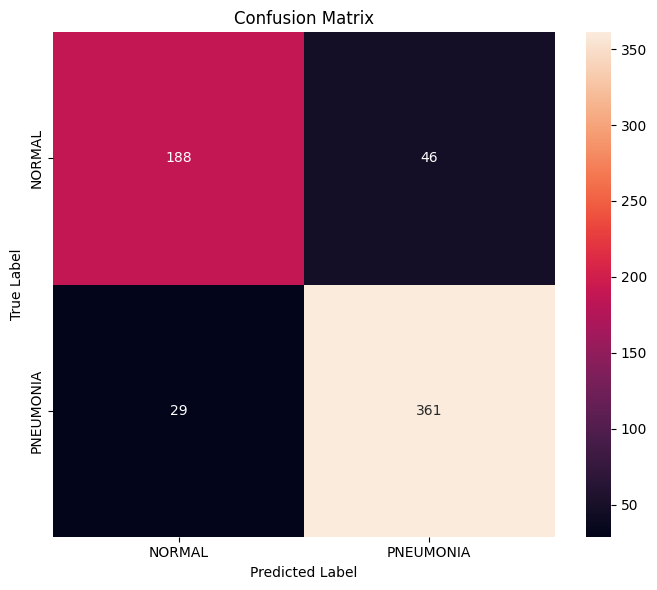

In [21]:
cm = confusion_matrix(
    true_labels, predicted_labels
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#**ROC Curve with AUC**

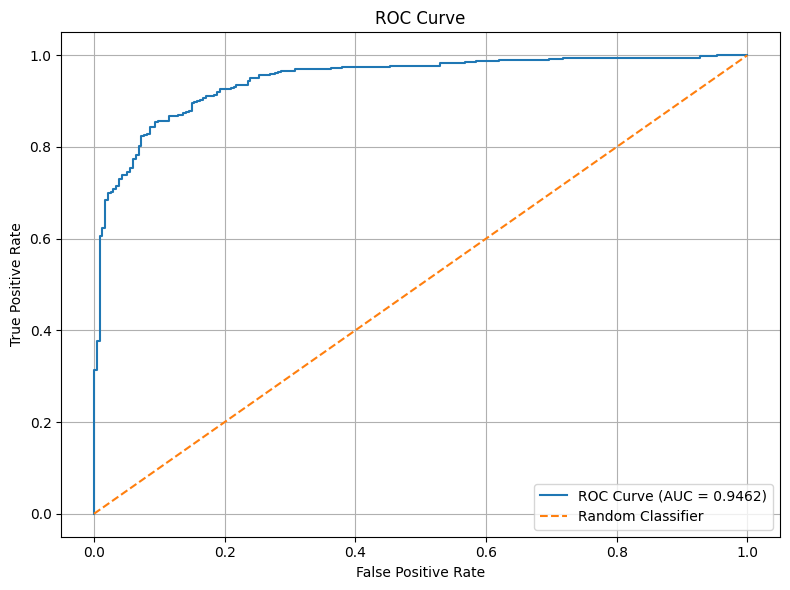

ROC-AUC Score: 0.9462


In [22]:
fp_rate, tp_rate, thresholds = roc_curve(
    true_labels, probabilities
)

auc_score = roc_auc_score(
    true_labels, probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fp_rate, tp_rate, label=f"ROC Curve (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1], [0, 1], linestyle="--", label="Random Classifier"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

#**Metrics Summary Table**

In [24]:
f1 = f1_score(
    true_labels, predicted_labels, zero_division=0
)

evaluation_metrics = pd.DataFrame({

    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],

    "Score": [accuracy, precision, recall, f1, auc_score],

    "Percentage": [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{auc_score * 100:.2f}%"
    ]

})

display(evaluation_metrics)

,Metric,Score,Percentage
0,Accuracy,0.879808,87.98%
1,Precision,0.886978,88.70%
2,Recall,0.925641,92.56%
3,F1 Score,0.905897,90.59%
4,ROC-AUC,0.946154,94.62%
